##**CustomerChurn**

**Dataset Link: https://drive.google.com/file/d/1haLnnbt5nWY_qXjg7oJbO3ztrDaToylO/view?usp=sharing**

**Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Configurational**

In [ ]:
from warnings import filterwarnings
filterwarnings('ignore')

**Load dataset**

In [ ]:
df = pd.read_csv('/content/customer_churn.csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Insights**
* Almost all of the columns are of object Data type
* There are some columns that seems to look like numeric column but actually they are object

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [ ]:
df.describe(include = 'O').T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [ ]:
# df['TotalCharges'].astype('float')

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
# error = 'coerce' --> It converts the error into null value

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df['TotalCharges'].isnull().sum()

np.int64(11)

**We will drop the null value**

In [ ]:
df.dropna(inplace = True)
# df = df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.drop(columns=['customerID'] ,inplace = True)

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


###**Data Analysis**

In [ ]:
df.Churn.value_counts(normalize = True)*100

,proportion
Churn,
No,73.421502
Yes,26.578498


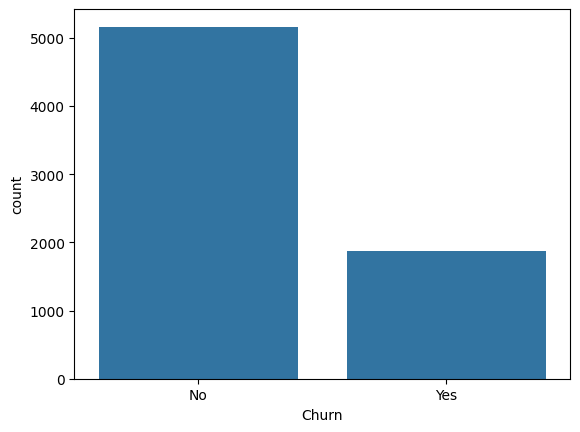

In [ ]:
sns.countplot(data =df, x = 'Churn')
plt.show()

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

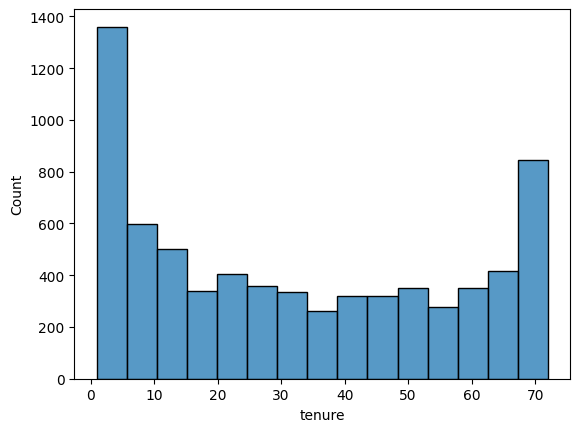

In [ ]:
sns.histplot(data = df, x = 'tenure')
plt.show()

In [ ]:
df['tenure'].skew() # +ve ---> Right skewed

np.float64(0.23773083190513133)

In [ ]:
df['tenure'].kurt() # -ve --> Platykurtic

np.float64(-1.3878225795553585)

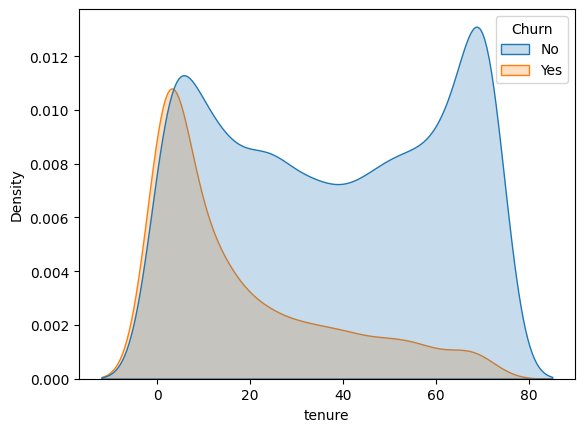

In [ ]:
sns.kdeplot(data = df, x = 'tenure',fill = True, hue = 'Churn')
plt.show()

**Analysis**
* Most churn happens early - Customer in their first few months are more likely to leave
* Long time customers rarely churns - loyality increases with tenure

**Graph Monthly charges vs Churn**

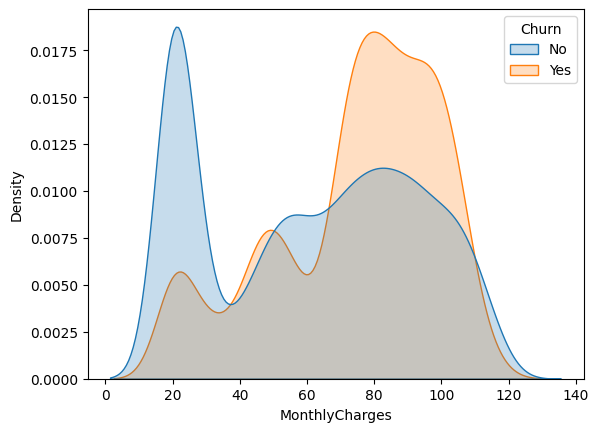

In [ ]:
sns.kdeplot(data = df, x = 'MonthlyCharges', hue = 'Churn', fill = True, common_norm=False)
plt.show()

**Insight**
* The more the monthly charges, More the churning rate will be

**Churn Based on internet services**

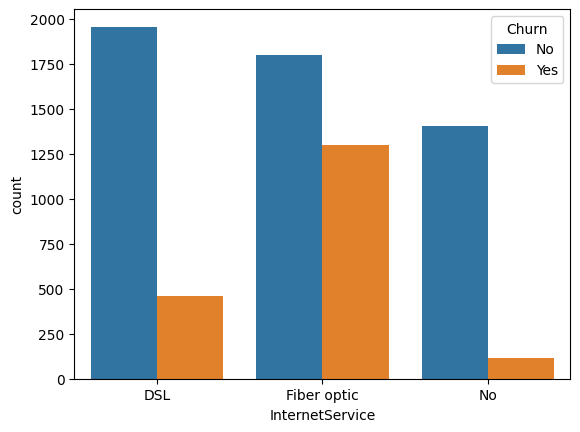

In [ ]:
sns.countplot(data = df, x ='InternetService', hue = 'Churn')
plt.show()

**Insight**
* Most of the people who choose fiber optics are churning, need to check the service

###**Data Preprocessing**

**We will now, encode the data**

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()

In [ ]:
for col in df.columns:
  if df[col].dtype == 'object' and col != 'Churn':
    df[col] = le.fit_transform(df[col])
    # Below this is just to show what value converted to what
    mapping = dict(zip(le.classes_ , le.transform(le.classes_)))
    print(f'Column: {col}')
    print(f'Original ----> Encoded')
    for orig, enc in mapping.items():
      print(f'{orig} ----> {enc}')
    print()

Column: gender
Original ----> Encoded
Female ----> 0
Male ----> 1

Column: Partner
Original ----> Encoded
No ----> 0
Yes ----> 1

Column: Dependents
Original ----> Encoded
No ----> 0
Yes ----> 1

Column: PhoneService
Original ----> Encoded
No ----> 0
Yes ----> 1

Column: MultipleLines
Original ----> Encoded
No ----> 0
No phone service ----> 1
Yes ----> 2

Column: InternetService
Original ----> Encoded
DSL ----> 0
Fiber optic ----> 1
No ----> 2

Column: OnlineSecurity
Original ----> Encoded
No ----> 0
No internet service ----> 1
Yes ----> 2

Column: OnlineBackup
Original ----> Encoded
No ----> 0
No internet service ----> 1
Yes ----> 2

Column: DeviceProtection
Original ----> Encoded
No ----> 0
No internet service ----> 1
Yes ----> 2

Column: TechSupport
Original ----> Encoded
No ----> 0
No internet service ----> 1
Yes ----> 2

Column: StreamingTV
Original ----> Encoded
No ----> 0
No internet service ----> 1
Yes ----> 2

Column: StreamingMovies
Original ----> Encoded
No ----> 0
No intern

In [ ]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,No
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   int64  
 7   InternetService   7032 non-null   int64  
 8   OnlineSecurity    7032 non-null   int64  
 9   OnlineBackup      7032 non-null   int64  
 10  DeviceProtection  7032 non-null   int64  
 11  TechSupport       7032 non-null   int64  
 12  StreamingTV       7032 non-null   int64  
 13  StreamingMovies   7032 non-null   int64  
 14  Contract          7032 non-null   int64  
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   int64  
 17  

**Let's Split into Dependent and independent features**

In [ ]:
x = df.drop(columns=['Churn'])
y = df['Churn']

In [ ]:
x.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65


In [ ]:
y.head()

,Churn
0,No
1,No
2,Yes
3,No
4,Yes


**Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.7,random_state=42)

In [ ]:
x_train.shape

(4922, 19)

In [ ]:
x_test.shape

(2110, 19)

**Building Model**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
df_model = DecisionTreeClassifier(random_state=42)
df_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_df = df_model.predict(x_test)

In [ ]:
from sklearn.metrics import *

In [ ]:
accuracy_score(y_pred_df,y_test)

0.7127962085308057

In [ ]:
print(classification_report(y_pred_df,y_test))

              precision    recall  f1-score   support

          No       0.79      0.81      0.80      1515
         Yes       0.49      0.46      0.48       595

    accuracy                           0.71      2110
   macro avg       0.64      0.64      0.64      2110
weighted avg       0.71      0.71      0.71      2110



**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(x_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(x_test)

In [ ]:
accuracy_score(y_pred_rf, y_test)

0.7829383886255924

In [ ]:
print(classification_report(y_pred_rf,y_test))

              precision    recall  f1-score   support

          No       0.89      0.83      0.86      1665
         Yes       0.49      0.62      0.54       445

    accuracy                           0.78      2110
   macro avg       0.69      0.72      0.70      2110
weighted avg       0.80      0.78      0.79      2110



**Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
log_model = LogisticRegression()

In [ ]:
log_model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred_log = log_model.predict(x_test)

In [ ]:
accuracy_score(y_pred_log, y_test)

0.7928909952606635

In [ ]:
print(classification_report(y_pred_log, y_test))

              precision    recall  f1-score   support

          No       0.88      0.84      0.86      1614
         Yes       0.55      0.62      0.59       496

    accuracy                           0.79      2110
   macro avg       0.72      0.73      0.72      2110
weighted avg       0.80      0.79      0.80      2110



In [ ]:
y_test.shape

(2110,)

**Let's Optimize Our model**

**Optuna**

It is a tool that automatically finds the best hyper parameters for a ML model

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 6.8 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.model_selection import cross_val_score

**We will define our objective function**

In [ ]:
def objective(trail):

  n_estimators = trail.suggest_int('n_estimators', 100 , 600)
  max_depth = trail.suggest_int('max_depth', 5 ,50)
  min_samples_leaf = trail.suggest_int('min_samples_leaf',1,10)
  min_samples_split = trail.suggest_int('min_samples_split',2,15)

  clf = RandomForestClassifier(
      n_estimators= n_estimators,
      max_depth= max_depth,
      min_samples_split= min_samples_split,
      min_samples_leaf= min_samples_leaf,
      random_state=42,
      n_jobs = -1 # it includes parllel processing (all the CPUs will be wised inside the model)
  )

  score = cross_val_score(clf,x_train, y_train, cv = 3, n_jobs = -1).mean()
  return score

In [ ]:
study = optuna.create_study(direction ='maximize') # We want to maximize the accuracy
study.optimize(objective,n_trials = 30) # It is going to run 30 different trails

[I 2025-12-28 16:01:01,455] A new study created in memory with name: no-name-bcea18c9-c9d9-473e-9e00-2b0388890358
[I 2025-12-28 16:01:20,870] Trial 0 finished with value: 0.7996766050841496 and parameters: {'n_estimators': 425, 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 14}. Best is trial 0 with value: 0.7996766050841496.
[I 2025-12-28 16:01:23,917] Trial 1 finished with value: 0.7988635969540683 and parameters: {'n_estimators': 115, 'max_depth': 9, 'min_samples_leaf': 8, 'min_samples_split': 4}. Best is trial 0 with value: 0.7996766050841496.
[I 2025-12-28 16:01:31,475] Trial 2 finished with value: 0.7988634730954255 and parameters: {'n_estimators': 558, 'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 9}. Best is trial 0 with value: 0.7996766050841496.
[I 2025-12-28 16:01:33,711] Trial 3 finished with value: 0.804146168061315 and parameters: {'n_estimators': 180, 'max_depth': 13, 'min_samples_leaf': 9, 'min_samples_split': 5}. Best is trial 3 with value:

In [ ]:
best_params = study.best_params
best_params

{'n_estimators': 180,
 'max_depth': 13,
 'min_samples_leaf': 9,
 'min_samples_split': 5}

In [ ]:
final_rf_optuna = RandomForestClassifier(**best_params, random_state =42)

In [ ]:
final_rf_optuna.fit(x_train, y_train)

RandomForestClassifier(max_depth=13, min_samples_leaf=9, min_samples_split=5,
                       n_estimators=180, random_state=42)

In [ ]:
y_pred_optuna = final_rf_optuna.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred_optuna)

0.8023696682464455

In [ ]:
print(classification_report(y_test,y_pred_optuna))

              precision    recall  f1-score   support

          No       0.83      0.92      0.87      1549
         Yes       0.68      0.49      0.57       561

    accuracy                           0.80      2110
   macro avg       0.75      0.70      0.72      2110
weighted avg       0.79      0.80      0.79      2110



**SMOTE Technique**

It stands for Synthetic Minority Over Sampling Technique
* It creates new synthetic data points for the minority class
* It does not copu existing rows
* it creates new data points by learning from nearby minorty samples

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(random_state = 42)

**Note: Never resample test data, otherwise we will leak the information**

In [ ]:
x_train_smote, y_train_smote = smote.fit_resample(x_train,y_train)

In [ ]:
y_train.value_counts()

,count
Churn,
No,3614
Yes,1308


In [ ]:
y_train_smote.value_counts()

,count
Churn,
Yes,3614
No,3614


In [ ]:
rf_optuna_SMOTE = RandomForestClassifier(**best_params, random_state =42)

In [ ]:
rf_optuna_SMOTE.fit(x_train_smote,y_train_smote)

RandomForestClassifier(max_depth=13, min_samples_leaf=9, min_samples_split=5,
                       n_estimators=180, random_state=42)

In [ ]:
y_pred_smote = rf_optuna_SMOTE.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred_smote)

0.7644549763033175

In [ ]:
print(classification_report(y_test,y_pred_smote))

              precision    recall  f1-score   support

          No       0.87      0.80      0.83      1549
         Yes       0.55      0.67      0.60       561

    accuracy                           0.76      2110
   macro avg       0.71      0.73      0.72      2110
weighted avg       0.78      0.76      0.77      2110

